# Разработка алгоритма расчета состояния прибытия с учетом кэширования существующих подразделений

In [4]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox

ox.__version__

'2.0.1'

In [117]:
G = ox.load_graphml('data/gds.ml')

# Функции

In [105]:
from itertools import count

from networkx import multi_source_dijkstra
from genesis.core import StateBase
from genesis.swiss_knife import DELAY_TIME, MSF
from genesis.tools import get_duplicates_list

from heapq import heappush, heappop


def _dijkstra_multisource_cache(
    G, sources, weight, pred=None, paths=None, cutoff=None, target=None, seen=None
):

    G_succ = G._succ if G.is_directed() else G._adj

    push = heappush
    pop = heappop
    dist = {}  # dictionary of final distances
    # !!! передаем заранее как аргумент
    # seen = {}
    # fringe is heapq with 3-tuples (distance,c,node)
    # use the count c to avoid comparing nodes (may not be able to)
    c = count()
    fringe = []
    for source in sources:
        if source not in G:
            raise nx.NodeNotFound(f"Source {source} not in G")
        seen[source] = 0
        push(fringe, (0, next(c), source))
    while fringe:
        (d, _, v) = pop(fringe)
        if v in dist:
            continue  # already searched this node.
        dist[v] = d
        if v == target:
            break
        for u, e in G_succ[v].items():
            cost = weight(v, u, e)
            if cost is None:
                continue
            vu_dist = dist[v] + cost
            if cutoff is not None:
                if vu_dist > cutoff:
                    continue
            if u in dist:
                u_dist = dist[u]
                if vu_dist < u_dist:
                    raise ValueError("Contradictory paths found:", "negative weights?")
                elif pred is not None and vu_dist == u_dist:
                    pred[u].append(v)
            elif u not in seen or vu_dist < seen[u]:
                seen[u] = vu_dist
                push(fringe, (vu_dist, next(c), u))
                if paths is not None:
                    paths[u] = paths[v] + [u]
                if pred is not None:
                    pred[u] = [v]
            elif vu_dist == seen[u]:
                if pred is not None:
                    pred[u].append(v)

    # The optional predecessor and path dictionaries can be accessed
    # by the caller via the pred and paths objects passed as arguments.
    return dist

def _weight_function_cache(G, weight):
    """Returns a function that returns the weight of an edge.

    The returned function is specifically suitable for input to
    functions :func:`_dijkstra` and :func:`_bellman_ford_relaxation`.

    Parameters
    ----------
    G : NetworkX graph.

    weight : string or function
        If it is callable, `weight` itself is returned. If it is a string,
        it is assumed to be the name of the edge attribute that represents
        the weight of an edge. In that case, a function is returned that
        gets the edge weight according to the specified edge attribute.

    Returns
    -------
    function
        This function returns a callable that accepts exactly three inputs:
        a node, an node adjacent to the first one, and the edge attribute
        dictionary for the eedge joining those nodes. That function returns
        a number representing the weight of an edge.

    If `G` is a multigraph, and `weight` is not callable, the
    minimum edge weight over all parallel edges is returned. If any edge
    does not have an attribute with key `weight`, it is assumed to
    have weight one.

    """
    if callable(weight):
        return weight
    # If the weight keyword argument is not callable, we assume it is a
    # string representing the edge attribute containing the weight of
    # the edge.
    if G.is_multigraph():
        return lambda u, v, d: min(attr.get(weight, 1) for attr in d.values())
    return lambda u, v, data: data.get(weight, 1)


def multi_source_dijkstra_cache(seen=None):
    def multi_source_dijkstra_cache_(G, sources, target=None, cutoff=None, weight="weight"):
        """Find shortest weighted paths and lengths from a given set of
        source nodes.

        Uses Dijkstra's algorithm to compute the shortest paths and lengths
        between one of the source nodes and the given `target`, or all other
        reachable nodes if not specified, for a weighted graph.

        Parameters
        ----------
        G : NetworkX graph

        sources : non-empty set of nodes
            Starting nodes for paths. If this is just a set containing a
            single node, then all paths computed by this function will start
            from that node. If there are two or more nodes in the set, the
            computed paths may begin from any one of the start nodes.

        target : node label, optional
            Ending node for path

        cutoff : integer or float, optional
            Length (sum of edge weights) at which the search is stopped.
            If cutoff is provided, only return paths with summed weight <= cutoff.

        weight : string or function
            If this is a string, then edge weights will be accessed via the
            edge attribute with this key (that is, the weight of the edge
            joining `u` to `v` will be ``G.edges[u, v][weight]``). If no
            such edge attribute exists, the weight of the edge is assumed to
            be one.

            If this is a function, the weight of an edge is the value
            returned by the function. The function must accept exactly three
            positional arguments: the two endpoints of an edge and the
            dictionary of edge attributes for that edge. The function must
            return a number.

        Returns
        -------
        distance, path : pair of dictionaries, or numeric and list
            If target is None, returns a tuple of two dictionaries keyed by node.
            The first dictionary stores distance from one of the source nodes.
            The second stores the path from one of the sources to that node.
            If target is not None, returns a tuple of (distance, path) where
            distance is the distance from source to target and path is a list
            representing the path from source to target.

        Examples
        --------
        >>> G = nx.path_graph(5)
        >>> length, path = nx.multi_source_dijkstra(G, {0, 4})
        >>> for node in [0, 1, 2, 3, 4]:
        ...     print(f"{node}: {length[node]}")
        0: 0
        1: 1
        2: 2
        3: 1
        4: 0
        >>> path[1]
        [0, 1]
        >>> path[3]
        [4, 3]

        >>> length, path = nx.multi_source_dijkstra(G, {0, 4}, 1)
        >>> length
        1
        >>> path
        [0, 1]

        Notes
        -----
        Edge weight attributes must be numerical.
        Distances are calculated as sums of weighted edges traversed.

        The weight function can be used to hide edges by returning None.
        So ``weight = lambda u, v, d: 1 if d['color']=="red" else None``
        will find the shortest red path.

        Based on the Python cookbook recipe (119466) at
        https://code.activestate.com/recipes/119466/

        This algorithm is not guaranteed to work if edge weights
        are negative or are floating point numbers
        (overflows and roundoff errors can cause problems).

        Raises
        ------
        ValueError
            If `sources` is empty.
        NodeNotFound
            If any of `sources` is not in `G`.

        See Also
        --------
        multi_source_dijkstra_path
        multi_source_dijkstra_path_length

        """
        if not sources:
            raise ValueError("sources must not be empty")
        if target in sources:
            return (0, [target])
        weight = _weight_function_cache(G, weight)
        paths = {source: [source] for source in sources}  # dictionary of paths
        dist = _dijkstra_multisource_cache(
            G, sources, weight, paths=paths, cutoff=cutoff, target=target, seen=seen
        )
        if target is None:
            return (dist, paths)
        try:
            return (dist[target], paths[target])
        except KeyError as e:
            raise nx.NetworkXNoPath(f"No path to {target}.") from e
    
    return multi_source_dijkstra_cache_
    




# g_nodes = list(G.nodes())
# static = {
#     g_nodes[1000]: 'псч 1',
#     g_nodes[2000]: 'псч 2',
# }
# dynamic = {g_nodes[3000]: 'псч 3'}


# times, paths = multi_source_dijkstra(G, sources=static.keys(), weight='travel_time')
# print(len(times), len(paths))
# times2, paths2 = multi_source_dijkstra_cache(seen=times)(G, sources=dynamic.keys(), weight='travel_time')
# print(len(times2), len(paths2))

In [128]:
from genesis.states import FirstArrivalUnitState

g_nodes = list(G.nodes())
static = {
    g_nodes[10000]: 'псч 1',
    g_nodes[2000]: 'псч 2',
    g_nodes[3500]: 'псч 3',
}
times, nearest = FirstArrivalUnitState(multi_source_dijkstra)(G, points=static)
print(len(times), len(nearest))


43089 43089


In [129]:
dynamic = {
    g_nodes[5000]: 'псч 4',
    g_nodes[6000]: 'псч 5',
    }
times2, nearest2 = FirstArrivalUnitState(multi_source_dijkstra_cache(seen=times))(G, points=dynamic)
print(len(times2), len(nearest2))

nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, nearest2, 'nearest')
nx.set_node_attributes(G, times, 'times')

25965 25965


<Axes: >

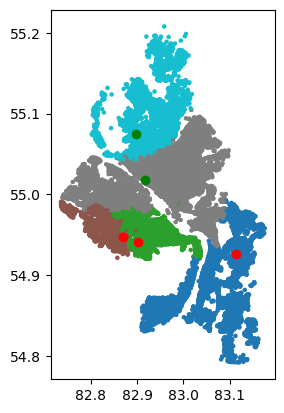

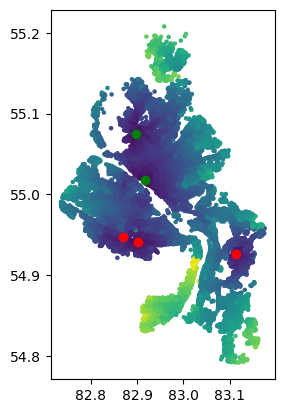

In [130]:
nodes = ox.graph_to_gdfs(G, edges=False)
ax = nodes.plot(column='nearest', markersize=5)
nodes.loc[static.keys()].plot(ax=ax, color='r')
nodes.loc[dynamic.keys()].plot(ax=ax, color='g')

ax2 = nodes.plot(column='times', markersize=5)
nodes.loc[static.keys()].plot(ax=ax2, color='r')
nodes.loc[dynamic.keys()].plot(ax=ax2, color='g')

In [125]:
print('='*80)